In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
import warnings
warnings.filterwarnings("ignore")

# File Paths
BASE = r"C:\Users\vimuk\Documents\Y2S1\AIML\2025-Y2-S1-MLB-B12G2-10"
DATA_PATH = os.path.join(BASE, "data", "processed", "Student_Performance_cleaned.csv")
RESULTS_DIR = os.path.join(BASE, "results")
METRICS_DIR = os.path.join(RESULTS_DIR, "metrics")
MODEL_OUTPUT_DIR = os.path.join(RESULTS_DIR, "model_outputs", "trained_models")
os.makedirs(METRICS_DIR, exist_ok=True)
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)
MY_RESULTS_CSV = os.path.join(METRICS_DIR, "IT24103553_results.csv")
MY_MODEL_PKL = os.path.join(MODEL_OUTPUT_DIR, "IT24103553_best_model.pkl")
MY_METADATA_JSON = os.path.join(MODEL_OUTPUT_DIR, "IT24103553_model_info.json")
RANDOM_STATE = 42

In [2]:
df = pd.read_csv(DATA_PATH)
print("Dataset Shape:", df.shape)
display(df.head())
print("\nMissing values per column:\n", df.isnull().sum())

Dataset Shape: (9873, 7)


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index,StudyEfficiency
0,7,99,1,9,1,91.0,0.700000
1,4,82,0,4,2,65.0,0.800000
2,8,51,1,7,2,45.0,1.000000
3,5,52,1,5,2,36.0,0.833333
4,7,75,0,8,5,66.0,0.777778



Missing values per column:
 Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
StudyEfficiency                     0
dtype: int64


In [3]:
# Feature Selection
FEATURES = ["Hours Studied", "Previous Scores", "Extracurricular Activities",
            "Sleep Hours", "Sample Question Papers Practiced", "StudyEfficiency"]
TARGET = "Performance Index"

X = df[FEATURES]
y = df[TARGET]

In [4]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

In [5]:
# Feature Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Evaluation Function
def evaluate(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} - MAE: {mae:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}")
    return mae, rmse, r2

In [7]:
# Results DataFrame & Safe Append Function
results = pd.DataFrame(columns=["Model","MAE","RMSE","R2"])

def add_result(df, model_name, mae, rmse, r2):
    new_row_dict = {col: None for col in df.columns}
    new_row_dict.update({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })
    new_row = pd.DataFrame([new_row_dict], columns=df.columns)
    return pd.concat([df, new_row], ignore_index=True)

# Gradient Boosting Models

# Base GBR
gbr_base = GradientBoostingRegressor(random_state=RANDOM_STATE)
gbr_base.fit(X_train_scaled, y_train)
y_pred_base = gbr_base.predict(X_test_scaled)
mae, rmse, r2 = evaluate(y_test, y_pred_base, "GBR Base")
results = add_result(results, "GBR Base", mae, rmse, r2)

# GBR with tuned n_estimators & max_depth
gbr_tuned = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=RANDOM_STATE)
gbr_tuned.fit(X_train_scaled, y_train)
y_pred_tuned = gbr_tuned.predict(X_test_scaled)
mae, rmse, r2 = evaluate(y_test, y_pred_tuned, "GBR Tuned")
results = add_result(results, "GBR Tuned", mae, rmse, r2)

# GridSearchCV tuning
gbr = GradientBoostingRegressor(random_state=RANDOM_STATE)
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0]
}
grid_search = GridSearchCV(gbr, param_grid, cv=5, scoring="r2", n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
best_gbr = grid_search.best_estimator_
y_pred_grid = best_gbr.predict(X_test_scaled)
mae, rmse, r2 = evaluate(y_test, y_pred_grid, "GBR Grid Search")
results = add_result(results, "GBR Grid Search", mae, rmse, r2)

GBR Base - MAE: 1.696, RMSE: 2.140, R2: 0.988
GBR Tuned - MAE: 1.682, RMSE: 2.122, R2: 0.988
GBR Grid Search - MAE: 1.687, RMSE: 2.127, R2: 0.988


In [8]:
# Select Best Model

best_row = results.loc[results["R2"].idxmax()]
best_model_name = best_row["Model"]
print(f"\nBest GBR Model: {best_model_name}")
display(best_row)


Best GBR Model: GBR Tuned


Model    GBR Tuned
MAE       1.682309
RMSE      2.122385
R2        0.987896
Name: 1, dtype: object

,Model,MAE,RMSE,R2
0,GBR Tuned,1.682309,2.122385,0.987896
1,GBR Grid Search,1.686751,2.126707,0.987847
2,GBR Base,1.695937,2.139519,0.987700


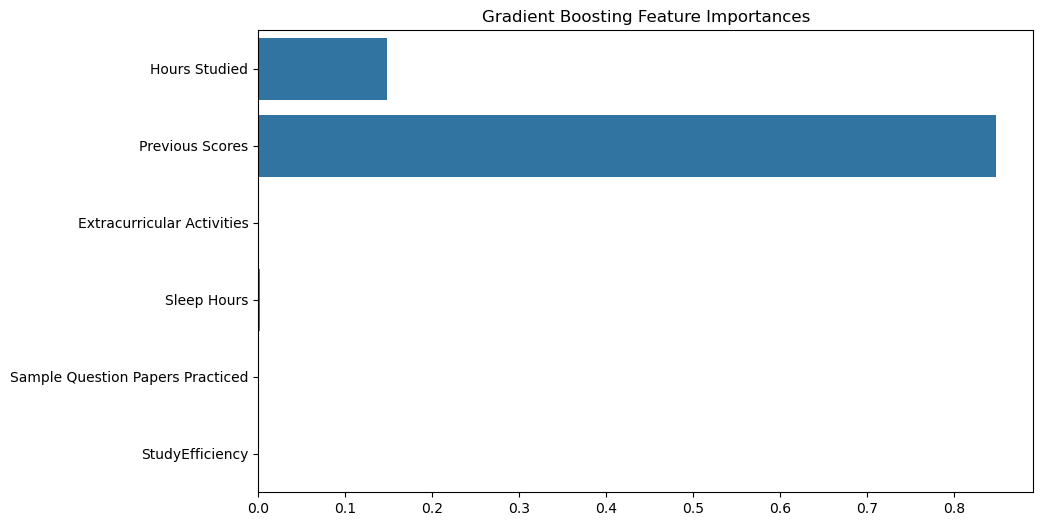

In [9]:
results = results.sort_values(by="R2", ascending=False).reset_index(drop=True)
display(results)
results.to_csv(MY_RESULTS_CSV, index=False)
joblib.dump(best_gbr, MY_MODEL_PKL)
model_info = {
    "best_params": grid_search.best_params_,
    "cv_results": {k: v.tolist() if isinstance(v, np.ndarray) else v for k,v in grid_search.cv_results_.items()},
    "features": FEATURES,
    "target": TARGET,
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist()
}

with open(MY_METADATA_JSON, "w") as f:
    json.dump(model_info, f, indent=4)

# Feature Importance Plot
importances = best_gbr.feature_importances_
plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=FEATURES)
plt.title("Gradient Boosting Feature Importances")
plt.show()